In [1]:
import os 
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import h5py
import numpy as np 


from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.lines import Line2D
from PIL import Image

plt.rc('axes', linewidth=3, labelsize=20)
plt.rc('xtick', labelsize=20)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=20)  # fontsize of the y tick labels

sns.set_context("talk")
sns.set(font_scale=1.5)
sns.set_style("white")

%matplotlib inline

In [2]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    broadened_dos_normalized = broadened_dos / broadened_area
    return 3*unit_cell_atoms*broadened_dos_normalized

In [4]:
results_directory={"../results/gromacs/pore/4nm/dry/results/md_prod_100/":("PoreMS",100,"β-cristobalite","Nanopore","crystal")
                   ,"../results/gromacs/pore/4nm/dry/results/md_prod_200/":("PoreMS",200,"β-cristobalite","Nanopore","crystal")
                   ,"../results/gromacs/pore/4nm/dry/results/md_prod_300/":("PoreMS",300,"β-cristobalite","Nanopore","crystal")
                   ,"../results/gromacs/pore/4nm/dry/results/md_prod_50/":("PoreMS",50,"β-cristobalite","Nanopore","crystal")
                   ,"../results/gromacs/bulk/beta_cristobalite/results/md_prod_100/":("PoreMS",100,"β-cristobalite","Bulk","crystal")
                   ,"../results/gromacs/bulk/beta_cristobalite/results/md_prod_200/":("PoreMS",200,"β-cristobalite","Bulk","crystal")
                   ,"../results/gromacs/bulk/beta_cristobalite/results/md_prod_300/":("PoreMS",300,"β-cristobalite","Bulk","crystal")
                  }
df_list=list()

min_energy=0
max_energy=150

for data_directory,(force_field,temperature,structure,sys, kind) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array

        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Weight"]=" ".join(filename.split("_")[:-1]).replace('b ','').capitalize()
        df_tmp["Method"]="MD"
        df_tmp["System"]=sys
        df_tmp["Structure"]=structure
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
        for species in ["Si","O"]:
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species)
            df_tmp[species]/=df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
        df_tmp["Kind"]=kind
                
        df_tmp["Temperature (K)"]=temperature
        df_tmp["Software"]=directory_split[2]
        
        df_list.append(df_tmp)
        
df_dos_gromacs=pd.concat(df_list,ignore_index=True)

../results/gromacs/pore/4nm/dry/results/md_prod_100/b_coherent_dos.h5
../results/gromacs/pore/4nm/dry/results/md_prod_100/b_incoherent_dos.h5
../results/gromacs/pore/4nm/dry/results/md_prod_200/b_coherent_dos.h5
../results/gromacs/pore/4nm/dry/results/md_prod_200/b_incoherent_dos.h5
../results/gromacs/pore/4nm/dry/results/md_prod_300/b_coherent_dos.h5
../results/gromacs/pore/4nm/dry/results/md_prod_300/b_incoherent_dos.h5
../results/gromacs/pore/4nm/dry/results/md_prod_50/b_coherent_dos.h5
../results/gromacs/pore/4nm/dry/results/md_prod_50/b_incoherent_dos.h5
../results/gromacs/bulk/beta_cristobalite/results/md_prod_100/b_coherent_dos.h5
../results/gromacs/bulk/beta_cristobalite/results/md_prod_100/b_incoherent_dos.h5
../results/gromacs/bulk/beta_cristobalite/results/md_prod_200/b_coherent_dos.h5
../results/gromacs/bulk/beta_cristobalite/results/md_prod_200/b_incoherent_dos.h5
../results/gromacs/bulk/beta_cristobalite/results/md_prod_300/b_coherent_dos.h5
../results/gromacs/bulk/beta_c

In [5]:
df_dos_gromacs

,dos O (nm2/ps),dos Si (nm2/ps),dos si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Weight,Method,System,...,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Kind,Temperature (K),Software
0,-0.000003,-0.000011,1.455540e-05,1.058104e-06,0.125676,0.0,1.0,Coherent,MD,Nanopore,...,PoreMS,0.082720,0.000578,-0.103515,-0.019616,0.009725,0.511136,crystal,100,gromacs
1,0.000003,0.000011,-9.792425e-06,6.434648e-07,0.251353,0.0,1.0,Coherent,MD,Nanopore,...,PoreMS,0.165440,0.000088,0.027238,0.006263,0.001479,0.038855,crystal,100,gromacs
2,-0.000002,-0.000010,1.845555e-05,2.490087e-06,0.377029,0.0,1.0,Coherent,MD,Nanopore,...,PoreMS,0.248160,0.000680,-0.049290,-0.007388,0.011443,0.200480,crystal,100,gromacs
3,0.000005,0.000012,-2.003338e-07,4.472725e-06,0.502705,0.0,1.0,Coherent,MD,Nanopore,...,PoreMS,0.330881,0.000611,0.028305,0.010259,0.010277,0.135039,crystal,100,gromacs
4,-0.000003,-0.000010,1.971547e-05,2.010537e-06,0.628381,0.0,1.0,Coherent,MD,Nanopore,...,PoreMS,0.413601,0.000549,-0.049672,-0.011761,0.009240,0.097123,crystal,100,gromacs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25377,0.000004,0.000002,NaN,2.840187e-06,227.348384,0.0,1.0,Incoherent,MD,Bulk,...,PoreMS,149.640707,0.000237,0.004041,0.006120,0.005246,0.000240,crystal,300,gromacs
25378,0.000004,0.000002,NaN,2.936470e-06,227.474061,0.0,1.0,Incoherent,MD,Bulk,...,PoreMS,149.723427,0.000236,0.004019,0.006085,0.005216,0.000239,crystal,300,gromacs
25379,0.000004,0.000002,NaN,2.788776e-06,227.599737,0.0,1.0,Incoherent,MD,Bulk,...,PoreMS,149.806147,0.000235,0.003996,0.006050,0.005186,0.000237,crystal,300,gromacs
25380,0.000004,0.000002,NaN,2.928931e-06,227.725413,0.0,1.0,Incoherent,MD,Bulk,...,PoreMS,149.888867,0.000233,0.003974,0.006015,0.005157,0.000236,crystal,300,gromacs


In [6]:
results_directory={"../results/lammps/pore/alpha_quartz/vashishta/4nm/dry/results/mdanse/":("VFF1990","α-quartz","Nanopore","crystal")
                   ,"../results/lammps/pore/alpha_quartz/reaxff2023/4nm/dry/results/mdanse/":("ReaxFF2023","α-quartz","Nanopore","crystal")
                   ,"../results/lammps/pore/amorphous/vashishta/4nm/dry/results/mdanse/":("VFF1990","Amorphous" ,"Nanopore","glass")
                   ,"../results/lammps/pore/amorphous/reaxff2023/4nm/dry/results/mdanse/":("ReaxFF2023","Amorphous","Nanopore","glass")
                    ,"../results/lammps/bulk/alpha_quartz/vashishta/results/mdanse/":("VFF1990","α-quartz" ,"Bulk","crystal")
                   ,"../results/lammps/bulk/alpha_quartz/reaxff2023/results/mdanse/":("ReaxFF2023","α-quartz" ,"Bulk","crystal")
                   ,"../results/lammps/bulk/amorphous/vashishta/results/mdanse/":("VFF1990","Amorphous"  ,"Bulk","glass")
                   ,"../results/lammps/bulk/amorphous/reaxff2023/results/mdanse/":("ReaxFF2023","Amorphous" ,"Bulk","glass")                  }
df_list=list()

min_energy=0
max_energy=150

for data_directory,(force_field,structure, sys,kind) in results_directory.items():
    for filename in os.listdir(data_directory):
        if not "dos.h5" in filename:
            continue
        print(os.path.join(data_directory,filename))
        h5file=h5py.File(os.path.join(data_directory,filename))
        data_dict=dict()
        omega_shape=h5file["omega"][:].shape
        for k in h5file.keys():
            data_array=h5file[k][:]
            if data_array.shape != omega_shape or "_0" in k:
                continue
            units=h5file[k].attrs['units']
            data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
        df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
        directory_split=data_directory.split("/")
        system=directory_split[3]
        df_tmp["Temperature (K)"]=int(filename.split("_")[2].replace('K',''))
        df_tmp["Weight"]=" ".join(filename.split("_")[:-2]).replace('b ','').capitalize()
        label="%s lammps"%(system.replace("_"," ").replace("nanoparticle", "np"))
        df_tmp["Method"]="MD"
        df_tmp["System"]=sys
        df_tmp["Structure"]=structure
        df_tmp["Force Field"]=force_field
        df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
        df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp,unit_cell_atoms=9)
        for species,unit_cell_atoms in {"Si":3,"O":6}.items():
            df_tmp[species]=apply_gaussian_broadening(df_tmp,"dos %s (nm2/ps)"%species,unit_cell_atoms)
            df_tmp[species]=df_tmp[species]/df_tmp[species].max()
        df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
        df_tmp["S(E)"]=df_tmp["Max Normalized Count"]/(df_tmp["Energy Transfer (meV)"]+np.finfo(float).eps)
        df_tmp["S(E)"]=df_tmp["S(E)"]/df_tmp["S(E)"].max()
        df_tmp["Software"]=directory_split[2]
        df_tmp["Kind"]=kind
        
        df_list.append(df_tmp)
df_dos_lammps=pd.concat(df_list,ignore_index=True)



../results/lammps/pore/alpha_quartz/vashishta/4nm/dry/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/pore/alpha_quartz/vashishta/4nm/dry/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/pore/alpha_quartz/vashishta/4nm/dry/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/pore/alpha_quartz/vashishta/4nm/dry/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/pore/alpha_quartz/vashishta/4nm/dry/results/mdanse/b_incoherent_200K_dos.h5
../results/lammps/pore/alpha_quartz/vashishta/4nm/dry/results/mdanse/b_incoherent_300K_dos.h5
../results/lammps/pore/alpha_quartz/reaxff2023/4nm/dry/results/mdanse/b_coherent_100K_dos.h5
../results/lammps/pore/alpha_quartz/reaxff2023/4nm/dry/results/mdanse/b_coherent_200K_dos.h5
../results/lammps/pore/alpha_quartz/reaxff2023/4nm/dry/results/mdanse/b_coherent_300K_dos.h5
../results/lammps/pore/alpha_quartz/reaxff2023/4nm/dry/results/mdanse/b_incoherent_100K_dos.h5
../results/lammps/pore/alpha_quartz/reaxff2023/4nm/dry/results/mdans

In [7]:
df_dos_md=pd.concat([df_dos_lammps,df_dos_gromacs])
df_dos_md

,dos O (nm2/ps),dos Si (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Temperature (K),Weight,Method,System,...,Force Field,Energy Transfer (meV),Normalized Count,Si,O,Max Normalized Count,S(E),Software,Kind,dos si (nm2/ps)
0,0.000008,2.411071e-07,0.000006,0.062838,0.0,1.0,100,Coherent,MD,Nanopore,...,VFF1990,0.041360,0.054479,0.006873,0.129214,0.108747,1.000000,lammps,crystal,NaN
1,-0.000007,5.905515e-07,-0.000005,0.125676,0.0,1.0,100,Coherent,MD,Nanopore,...,VFF1990,0.082720,-0.011012,0.004209,-0.027243,-0.021981,-0.101066,lammps,crystal,NaN
2,0.000008,2.040777e-07,0.000006,0.188514,0.0,1.0,100,Coherent,MD,Nanopore,...,VFF1990,0.124080,0.027341,0.002909,0.064956,0.054576,0.167286,lammps,crystal,NaN
3,-0.000007,4.907431e-07,-0.000005,0.251353,0.0,1.0,100,Coherent,MD,Nanopore,...,VFF1990,0.165440,-0.011413,0.003497,-0.028062,-0.022782,-0.052375,lammps,crystal,NaN
4,0.000008,1.857614e-07,0.000006,0.314191,0.0,1.0,100,Coherent,MD,Nanopore,...,VFF1990,0.206800,0.026985,0.002648,0.064156,0.053865,0.099066,lammps,crystal,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25377,0.000004,1.656522e-06,0.000003,227.348384,0.0,1.0,300,Incoherent,MD,Bulk,...,PoreMS,149.640707,0.000237,0.004041,0.006120,0.005246,0.000240,gromacs,crystal,NaN
25378,0.000004,2.231330e-06,0.000003,227.474061,0.0,1.0,300,Incoherent,MD,Bulk,...,PoreMS,149.723427,0.000236,0.004019,0.006085,0.005216,0.000239,gromacs,crystal,NaN
25379,0.000004,1.637400e-06,0.000003,227.599737,0.0,1.0,300,Incoherent,MD,Bulk,...,PoreMS,149.806147,0.000235,0.003996,0.006050,0.005186,0.000237,gromacs,crystal,NaN
25380,0.000004,2.217719e-06,0.000003,227.725413,0.0,1.0,300,Incoherent,MD,Bulk,...,PoreMS,149.888867,0.000233,0.003974,0.006015,0.005157,0.000236,gromacs,crystal,NaN


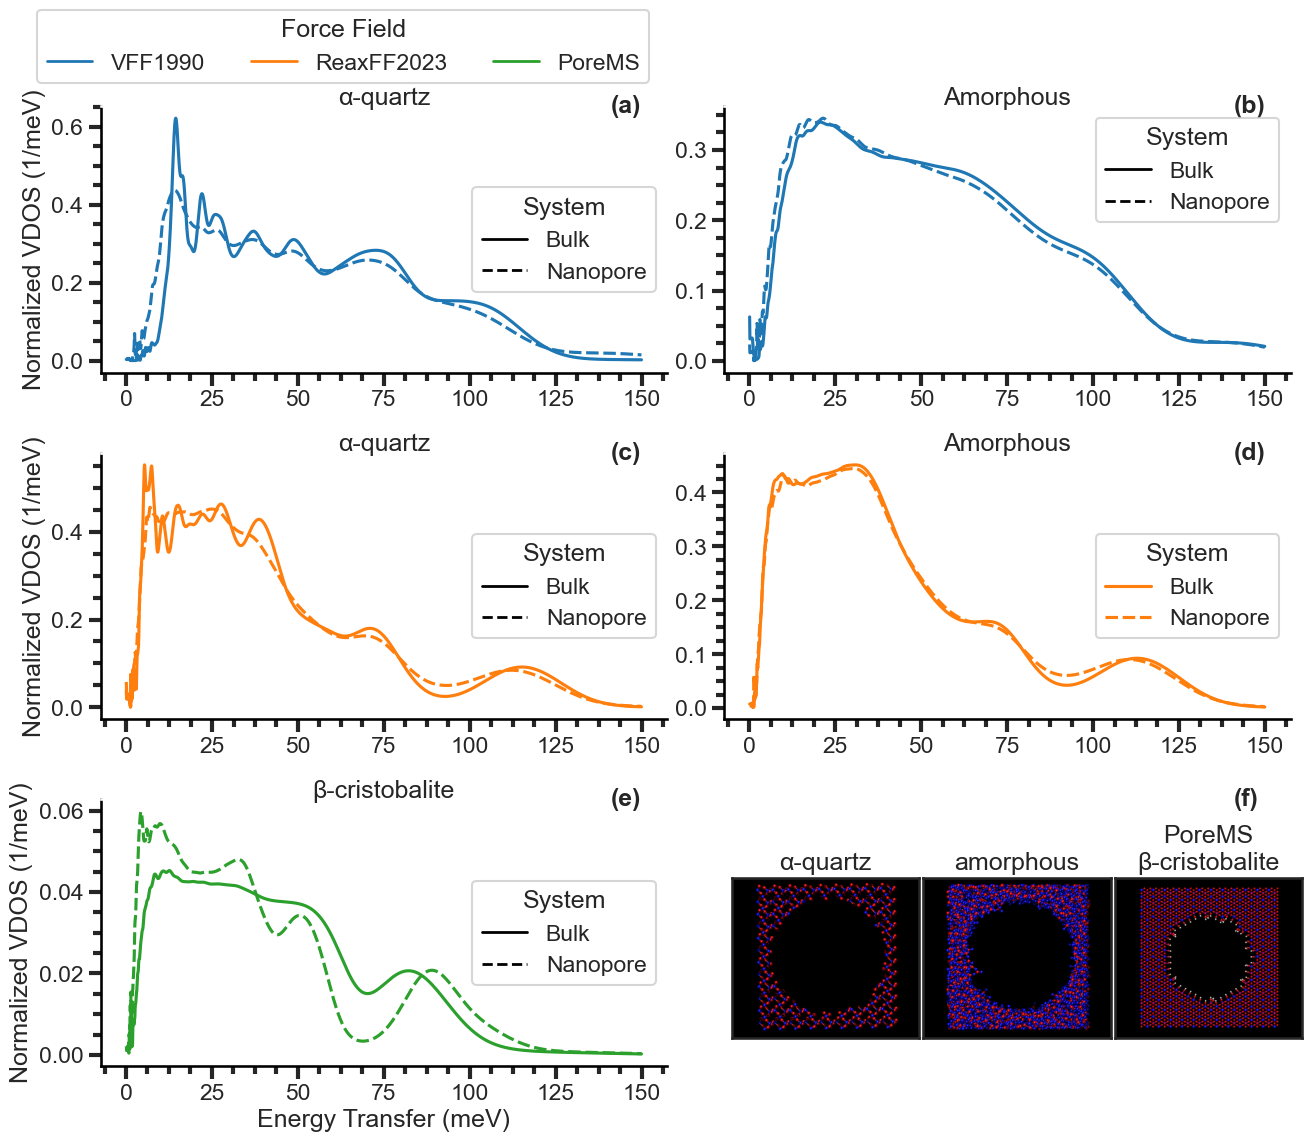

In [16]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(ncols=2,nrows=3,figsize=(7*2,4*3))
sns.set_context("talk")
palette=sns.color_palette("tab10")

labx=0.9
laby=0.975
index=["(%s)"%x for x in list("abcdef")]

force_fields=df_dos_md["Force Field"].unique()
kind_list=df_dos_md["Kind"].unique()
for j,force_field in enumerate(force_fields):
    for i, kind in enumerate(kind_list):
        ax=axs[j,i]
        
        ax.text(labx, laby, index[2*j+i],weight='bold' ,transform=ax.transAxes)

        if i== 1 and j == len(force_fields)-1:
            
            # Top-left square
            ax1 = inset_axes(ax, width="60%", height="60%", bbox_to_anchor=(-0.5, -0.25, 1, 1), bbox_transform=ax.transAxes)
            ax1.set_title("α-quartz")
            img = np.asarray(Image.open('../figures/structures/alpha_quartz_nanopore.png'))
            ax1.imshow(img)
            ax1.set_yticks([])
            ax1.set_xticks([])

            # Top-right square
            ax2 = inset_axes(ax, width="60%", height="60%", bbox_to_anchor=(-0.1625, -0.25, 1, 1), bbox_transform=ax.transAxes)
            img = np.asarray(Image.open('../figures/structures/amorphous_nanopore.png'))
            ax2.set_title("amorphous")
            ax2.imshow(img)
            ax2.set_yticks([])
            ax2.set_xticks([])

            # Bottom center square
            ax3 = inset_axes(ax, width="60%", height="60%", bbox_to_anchor=(0.175, -0.25, 1, 1), bbox_transform=ax.transAxes)
            img = np.asarray(Image.open('../figures/structures/PoreMS_nanopore.png'))
            ax3.set_title("PoreMS\nβ-cristobalite")
            ax3.imshow(img)
            ax3.set_yticks([])
            ax3.set_xticks([])

            ax.axis('off')
            ax.axis('tight')
            continue 

        df_tmp=df_dos_md.query("Weight== 'Incoherent' and Kind == '%s' and `S(E)` > 0 and `Force Field` == '%s' and `Temperature (K)` == 300 "%(kind,force_field))
        sns.lineplot(data=df_tmp
                    ,y="Normalized Count"
                    ,x='Energy Transfer (meV)'
                    ,ax=ax
                    ,style="System"
                    ,style_order=np.sort(df_dos_md["System"].unique())
                   ,color=palette[j]
#                    ,legend=i*j ==0
               )

        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
        ax.tick_params(which='both',direction='out', width=3, bottom=True, left=True)
        ax.grid(False)
        ax.set_ylabel("Normalized VDOS (1/meV)")

        
        ax.set_title(df_tmp["Structure"].unique()[0],y=0.975)


        if j < len(force_fields)-1:
            ax.set_xlabel("")
        if i >0:
            ax.set_ylabel("")
                        
        if i*j ==0:
            custom_lines = [Line2D([0], [0], color="black", lw=2)
                            ,Line2D([0], [0], color="black", lw=2,ls="dashed")
                            ,Line2D([0], [0], color="black", lw=2,ls="dotted")
                           ]
            ax.legend(custom_lines,np.sort(df_dos_md["System"].unique()),title="System")
            #sns.move_legend(ax,'center left',bbox_to_anchor=(0.5,0.95),ncol=6,bbox_transform=fig.transFigure)

        ax.minorticks_on()
        ax.xaxis.set_minor_locator(MultipleLocator(25/4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
            
custom_lines = [Line2D([0], [0], color=palette[0], lw=2)
                ,Line2D([0], [0], color=palette[1], lw=2)
                ,Line2D([0], [0], color=palette[2], lw=2)
               ]
ax.legend(custom_lines,list(force_fields),title="Force Field")
sns.move_legend(ax,'center right',bbox_to_anchor=(0.5,0.95),ncol=6,bbox_transform=fig.transFigure)


            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.1, 
                    hspace=0.3
                   )

plt.savefig("../figures/fig6.pdf", pad_inches=0.2,bbox_inches="tight")